# Lista de Exercícios – Regressão Linear com Base de Logística

## Problema: prever tempo de entrega

Neste notebook, vamos trabalhar com uma base simulada de uma empresa de entregas.

A empresa quer prever o **tempo de entrega em minutos** com base em características do pedido e da entrega.

## Objetivo geral

Criar modelos de regressão linear para prever:

> quanto tempo uma entrega deve demorar.

Essa é uma aplicação mais próxima de problemas reais de empresas, e-commerce, logística e sistemas de roteirização.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once mounted, you can list the contents of your Google Drive to verify. For example, to see the contents of your 'MyDrive' folder:

# Contexto da base

Cada linha representa um pedido entregue.

## Colunas

| Coluna | Descrição |
|---|---|
| id_pedido | Identificador do pedido |
| distancia_km | Distância entre loja/centro de distribuição e cliente |
| peso_kg | Peso total do pedido |
| qtd_itens | Quantidade de itens no pedido |
| valor_pedido | Valor total do pedido |
| trafego | Condição do tráfego: baixo, medio ou alto |
| clima | Condição climática: normal, chuva ou forte_chuva |
| tipo_entrega | normal ou expressa |
| regiao | centro, bairro ou zona_rural |
| tempo_entrega_min | Tempo de entrega em minutos |
| atrasou | Indica se a entrega passou de 120 minutos |

## Variável alvo para regressão

A variável que queremos prever é:

`tempo_entrega_min`

# Importação das bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Criando a base de dados

In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/exercicios/base_logistica_entregas.csv')

In [5]:
df

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
...,...,...,...,...,...,...,...,...,...,...,...
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim


# Parte A – Exploração inicial da base

## Exercício 1
Mostre as 10 primeiras linhas da base.

## Exercício 2
Mostre as 10 últimas linhas da base.

## Exercício 3
Use `.info()` para verificar os tipos de dados.

## Exercício 4
Use `.describe()` para analisar as variáveis numéricas.

## Exercício 5
Verifique se há valores nulos.

## Exercício 6
Quantas linhas e colunas existem?

## Exercício 7
Qual é a variável alvo do problema de regressão?

## Exercício 8
Quais variáveis parecem ser boas candidatas para prever tempo de entrega?

## Exercício 9
Quais variáveis são categóricas?

## Exercício 10
Por que não podemos usar variáveis categóricas diretamente na regressão linear sem tratamento?

In [ ]:
## Exercício 1
#Mostre as 10 primeiras linhas da base.\


In [ ]:
base = "/content/drive/MyDrive/exercicios/base_logistica_entregas.csv"

In [ ]:
df = pd.read_csv(base)
df.head(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.00,16.40,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.60,2.20,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.90,19.70,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.60,29.90,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.80,23.10,1,1899.66,medio,normal,expressa,bairro,158,sim
5,6,34.40,17.30,2,301.96,baixo,forte_chuva,normal,zona_rural,168,sim
6,7,78.50,3.30,10,2048.23,medio,normal,expressa,bairro,196,sim
7,8,55.10,21.10,1,443.68,baixo,normal,normal,centro,157,sim
8,9,39.00,19.90,8,1349.17,medio,normal,expressa,centro,158,sim
9,10,32.00,1.70,6,982.79,medio,normal,normal,centro,122,sim


In [ ]:
#formatação de variaveis float
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
# EX-02
df = pd.read_csv('/content/drive/MyDrive/exercicios/base_logistica_entregas.csv')
df.tail(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
190,191,17.30,2.80,4,1323.99,baixo,chuva,expressa,centro,61,nao
191,192,57.70,10.50,9,1929.33,medio,chuva,normal,bairro,212,sim
192,193,30.90,28.30,1,1558.34,medio,chuva,normal,zona_rural,175,sim
193,194,53.80,14.80,9,1268.27,medio,forte_chuva,normal,centro,235,sim
194,195,3.30,8.30,1,1504.90,medio,normal,normal,zona_rural,73,nao
195,196,51.20,10.90,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.50,6.50,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.80,12.80,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.40,6.70,3,2369.26,medio,chuva,normal,centro,165,sim
199,200,10.60,25.40,6,2290.93,medio,normal,normal,centro,133,sim


In [ ]:
#EX-03
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pedido          200 non-null    int64  
 1   distancia_km       200 non-null    float64
 2   peso_kg            200 non-null    float64
 3   qtd_itens          200 non-null    int64  
 4   valor_pedido       200 non-null    float64
 5   trafego            200 non-null    object 
 6   clima              200 non-null    object 
 7   tipo_entrega       200 non-null    object 
 8   regiao             200 non-null    object 
 9   tempo_entrega_min  200 non-null    int64  
 10  atrasou            200 non-null    object 
dtypes: float64(3), int64(3), object(5)
memory usage: 17.3+ KB


In [ ]:
#EX-04
df.describe()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
count,200.00,200.00,200.00,200.00,200.00,200.00
mean,100.50,40.76,14.81,5.95,1343.56,158.35
std,57.88,21.05,8.80,3.08,718.34,49.45
min,1.00,1.20,0.30,1.00,35.17,44.00
25%,50.75,25.08,7.30,3.00,705.65,126.00
50%,100.50,42.15,14.05,6.00,1352.88,158.50
75%,150.25,57.73,22.80,8.25,1934.77,189.25
max,200.00,79.60,29.90,11.00,2489.78,286.00


In [ ]:
#EX-05
df.isnull().values.any()

np.False_

In [ ]:
#EX-06
df.shape

(200, 11)

In [ ]:
#EX-07
tempo de entrega em minutos

In [ ]:
#EX-08
distancia e tipo de entrega

In [ ]:
#EX-09
id, trafego, clima, tipo de entrega, regiao, atrasou

In [ ]:
#EX-10
treinamento não será eficiente e viável


# Parte B – Estatística descritiva

## Exercício 11
Calcule a média do tempo de entrega.

## Exercício 12
Calcule a mediana do tempo de entrega.

## Exercício 13
Calcule o desvio padrão do tempo de entrega.

## Exercício 14
Calcule o tempo mínimo e máximo de entrega.

## Exercício 15
Calcule os quartis de `tempo_entrega_min`.

## Exercício 16
Interprete a diferença entre média e mediana.

## Exercício 17
Existe muita variação nos tempos de entrega? Use o desvio padrão para justificar.

## Exercício 18
Existe algum possível outlier no tempo de entrega?

## Exercício 19
Compare o tempo médio de entrega por tipo de entrega.

## Exercício 20
Compare o tempo médio de entrega por condição de tráfego.

In [ ]:
#EX-11
df['tempo_entrega_min'].mean()

np.float64(158.355)

In [ ]:
#EX-12
df['tempo_entrega_min'].median()

158.5

In [ ]:
#EX-13
df['tempo_entrega_min'].std()

49.45043683849101

In [ ]:
#EX-14
minimo = df['tempo_entrega_min'].min()
maximo = df['tempo_entrega_min'].max()
print(f'minimo: {minimo}, maximo: {maximo}')

minimo: 44, maximo: 286


In [ ]:
#EX-15
df['tempo_entrega_min'].quantile([0.25,0.5,0.75])

,tempo_entrega_min
0.25,126.00
0.50,158.50
0.75,189.25


In [ ]:
#EX-16
mediana valor central do tempo de entrega
media em relacao a todos os tempos de entrega

In [ ]:
#EX-17
#coeficiente de variacao
'''
CV < 0.1 (10%) → baixa variação
0.1 ≤ CV ≤ 0.3 → variação moderada
CV > 0.3 (30%) → alta variação
'''

coev = df['tempo_entrega_min'].std() / df['tempo_entrega_min'].mean()
print('Alta variação: ',coev)

Alta variação:  0.31227581597354687


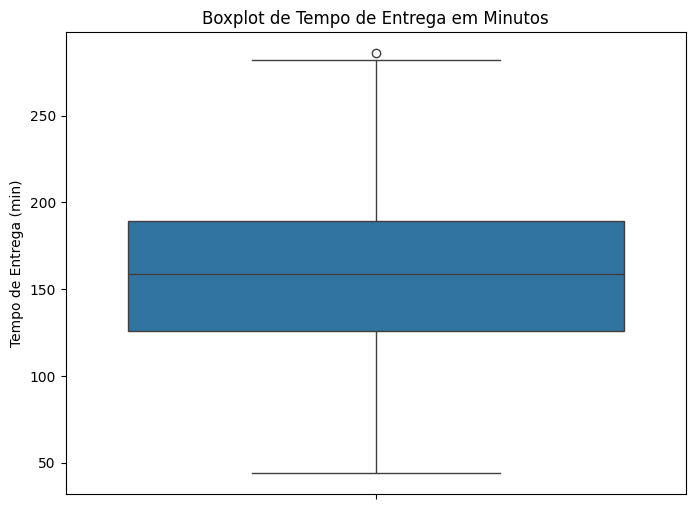

In [ ]:
#EX-18
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['tempo_entrega_min'])
plt.title('Boxplot de Tempo de Entrega em Minutos')
plt.ylabel('Tempo de Entrega (min)')
plt.show()

In [ ]:
#EX-19
df.groupby('tipo_entrega')['tempo_entrega_min'].mean()

,tempo_entrega_min
tipo_entrega,
expressa,149.89
normal,161.73


In [ ]:
#EX-20
df.groupby('trafego')['tempo_entrega_min'].mean()

,tempo_entrega_min
trafego,
alto,188.07
baixo,135.12
medio,162.31


-# Parte C – Visualização

## Exercício 21
Faça um histograma de `tempo_entrega_min`.

## Exercício 22
Faça um boxplot de `tempo_entrega_min`.

## Exercício 23
Faça um gráfico de dispersão entre `distancia_km` e `tempo_entrega_min`.

## Exercício 24
Faça um gráfico de dispersão entre `peso_kg` e `tempo_entrega_min`.

## Exercício 25
Faça um gráfico de dispersão entre `qtd_itens` e `tempo_entrega_min`.

## Exercício 26
Faça um boxplot de tempo de entrega por `trafego`.

## Exercício 27
Faça um boxplot de tempo de entrega por `clima`.

## Exercício 28
Faça um boxplot de tempo de entrega por `tipo_entrega`.

## Exercício 29
Visualmente, qual variável parece mais relacionada ao tempo de entrega?

## Exercício 30
O gráfico sugere relação linear entre distância e tempo?

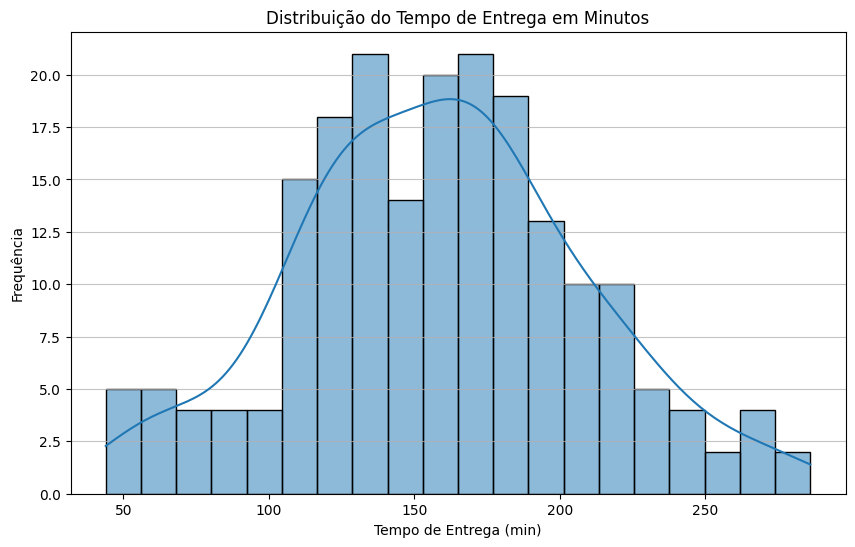

In [ ]:
#EX-21
plt.figure(figsize=(10, 6))
sns.histplot(df['tempo_entrega_min'], bins=20, kde=True)
plt.title('Distribuição do Tempo de Entrega em Minutos')
plt.xlabel('Tempo de Entrega (min)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

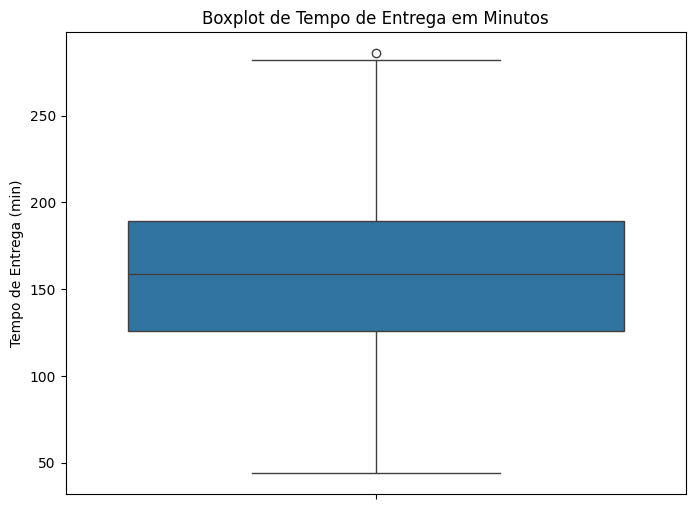

In [ ]:
#EX-22
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['tempo_entrega_min'])
plt.title('Boxplot de Tempo de Entrega em Minutos')
plt.ylabel('Tempo de Entrega (min)')
plt.show()

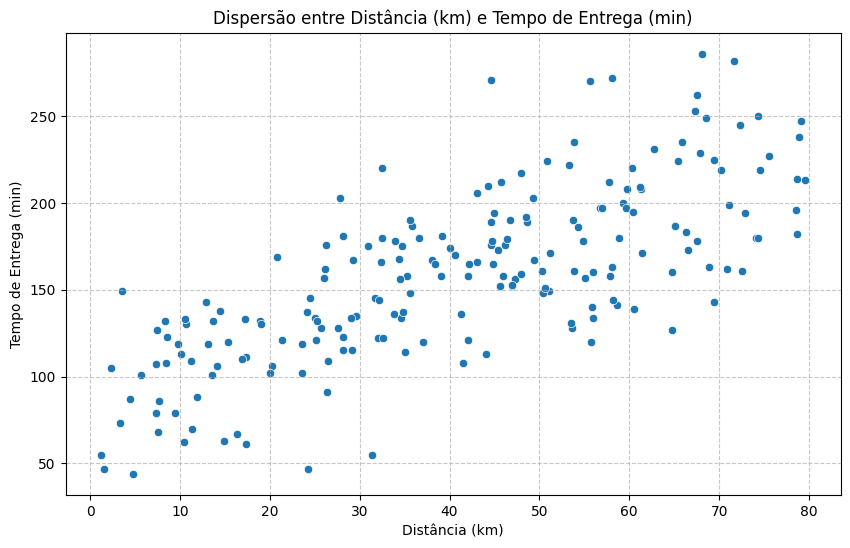

In [ ]:
#EX-23
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distancia_km', y='tempo_entrega_min', data=df)
plt.title('Dispersão entre Distância (km) e Tempo de Entrega (min)')
plt.xlabel('Distância (km)')
plt.ylabel('Tempo de Entrega (min)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

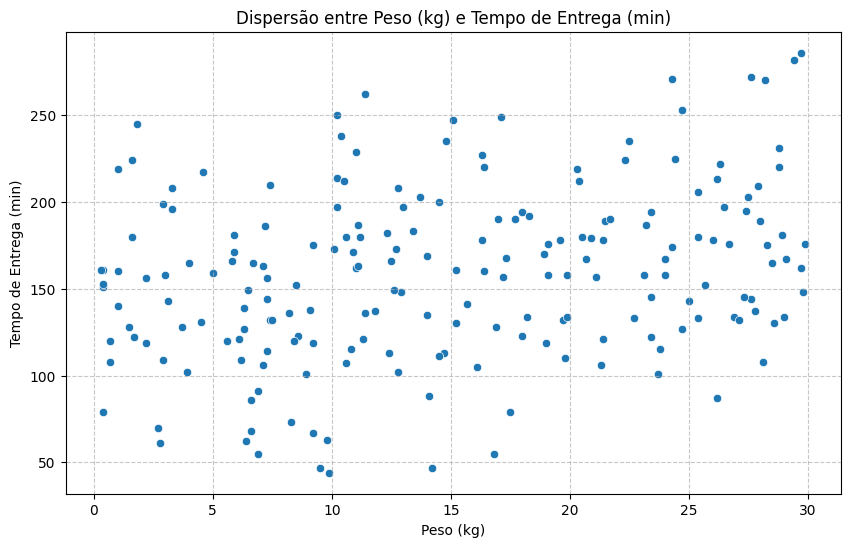

In [ ]:
#EX-24
plt.figure(figsize=(10, 6))
sns.scatterplot(x='peso_kg', y='tempo_entrega_min', data=df)
plt.title('Dispersão entre Peso (kg) e Tempo de Entrega (min)')
plt.xlabel('Peso (kg)')
plt.ylabel('Tempo de Entrega (min)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

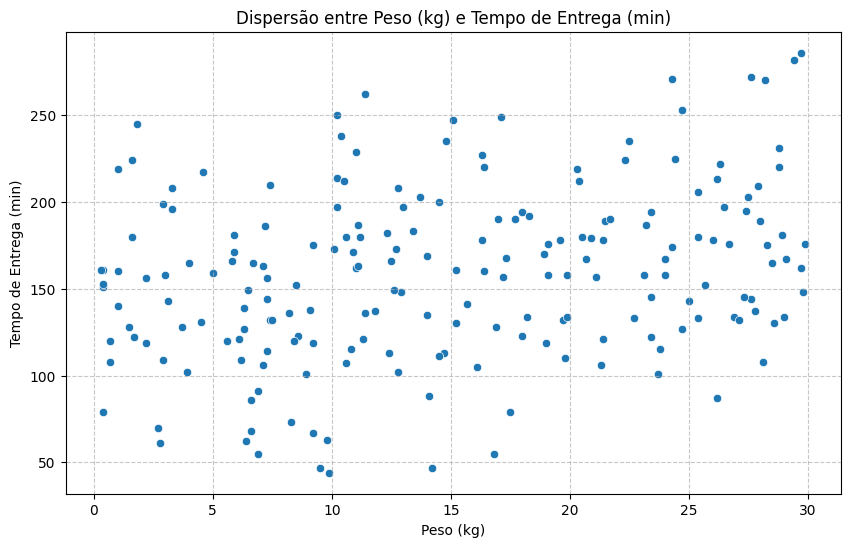

In [ ]:
#EX-24
plt.figure(figsize=(10, 6))
sns.scatterplot(x='peso_kg', y='tempo_entrega_min', data=df)
plt.title('Dispersão entre Peso (kg) e Tempo de Entrega (min)')
plt.xlabel('Peso (kg)')
plt.ylabel('Tempo de Entrega (min)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

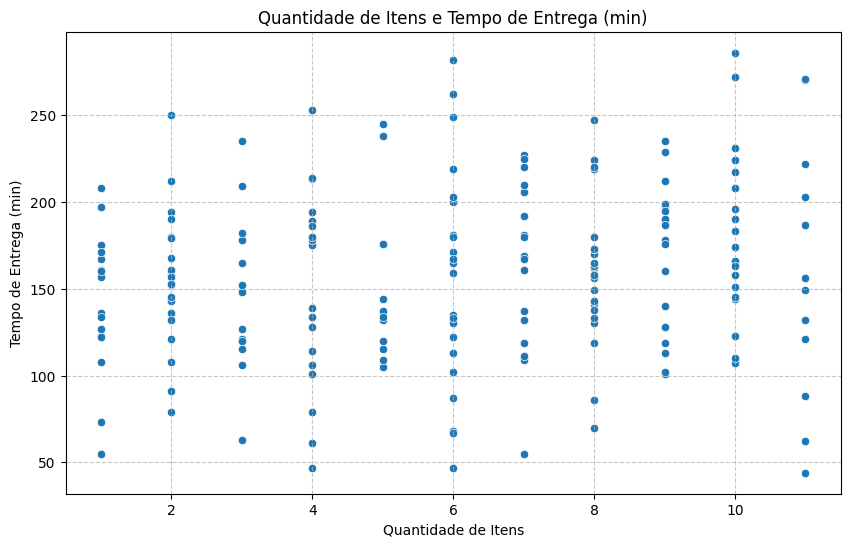

In [ ]:
#EX-25
plt.figure(figsize=(10, 6))
sns.scatterplot(x='qtd_itens', y='tempo_entrega_min', data=df)
plt.title('Quantidade de Itens e Tempo de Entrega (min)')
plt.xlabel('Quantidade de Itens')
plt.ylabel('Tempo de Entrega (min)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

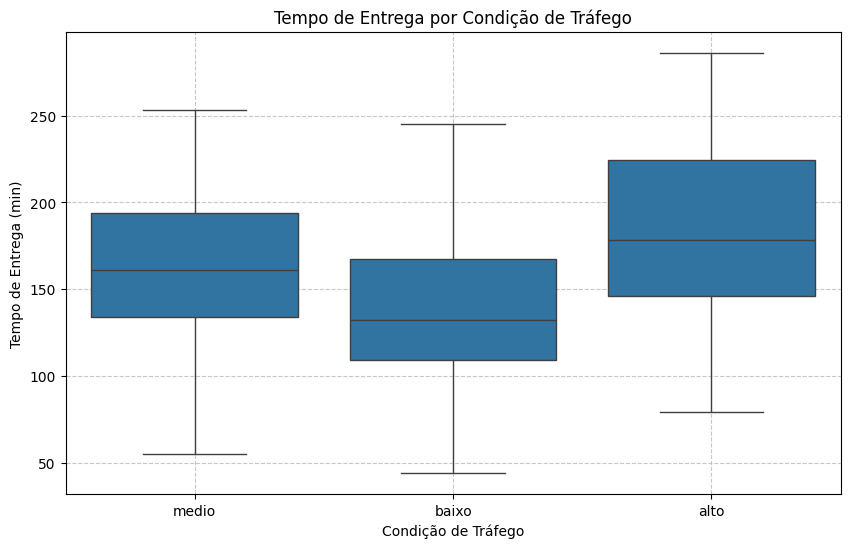

In [ ]:
#EX-26
plt.figure(figsize=(10, 6))
sns.boxplot(x='trafego', y='tempo_entrega_min', data=df)
plt.title('Tempo de Entrega por Condição de Tráfego')
plt.xlabel('Condição de Tráfego')
plt.ylabel('Tempo de Entrega (min)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#EX-27
plt.figure(figsize=(10, 6))
sns.boxplot(x='clima', y='tempo_entrega_min', data=df)
plt.title('Tempo de Entrega por Condição Climática')
plt.xlabel('Condição Climática')
plt.ylabel('Tempo de Entrega (min)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#EX-28
plt.figure(figsize=(10, 6))
sns.boxplot(x='tipo_entrega', y='tempo_entrega_min', data=df)
plt.title('Tempo de Entrega por Tipo de Entrega')
plt.xlabel('Tipo de Entrega')
plt.ylabel('Tempo de Entrega (min)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#EX-29
distancia_km

In [ ]:
#EX-30
SIM

# Parte D – Correlação

Para calcular correlação, use apenas variáveis numéricas.

## Exercício 31
Crie um DataFrame apenas com variáveis numéricas.

## Exercício 32
Calcule a matriz de correlação.

## Exercício 33
Faça um heatmap da matriz de correlação.

## Exercício 34
Qual variável numérica tem maior correlação positiva com `tempo_entrega_min`?

## Exercício 35
Qual variável numérica parece ter menor relação com `tempo_entrega_min`?

## Exercício 36
Correlação alta prova causalidade? Explique.

## Exercício 37
Se `valor_pedido` tiver baixa correlação com tempo, isso significa que nunca deve ser usado? Explique.

## Exercício 38
A variável `distancia_km` parece importante? Justifique.

## Exercício 39
A variável `peso_kg` parece importante? Justifique.

## Exercício 40
Quais variáveis você escolheria para um primeiro modelo simples?

In [ ]:
# EX-31
df_numerico = df.select_dtypes(include=['number'])
display(df_numerico.head())

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
0,1,56.00,16.40,9,2158.92,160
1,2,23.60,2.20,9,1431.91,119
2,3,18.90,19.70,5,464.30,132
3,4,44.60,29.90,5,1290.63,176
4,5,57.80,23.10,1,1899.66,158


In [ ]:
#EX-32
matriz_correlacao = df_numerico.corr()
display(matriz_correlacao)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
id_pedido,1.00,-0.01,0.02,-0.03,0.04,0.01
distancia_km,-0.01,1.00,-0.02,-0.04,-0.07,0.74
peso_kg,0.02,-0.02,1.00,0.02,-0.04,0.28
qtd_itens,-0.03,-0.04,0.02,1.00,0.13,0.16
valor_pedido,0.04,-0.07,-0.04,0.13,1.00,-0.05
tempo_entrega_min,0.01,0.74,0.28,0.16,-0.05,1.00


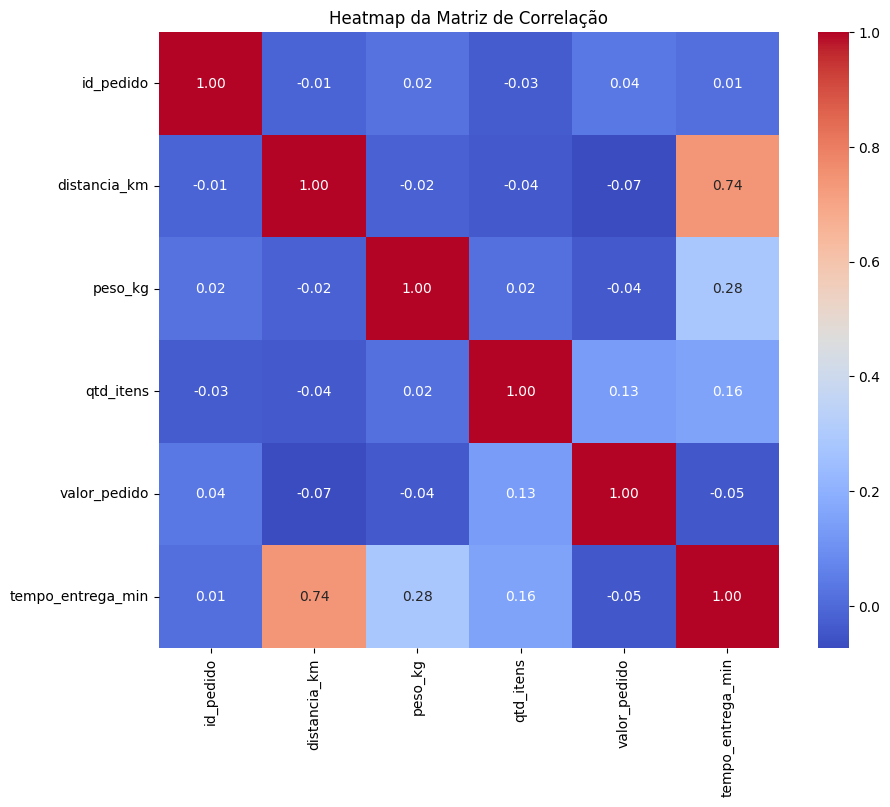

In [ ]:
#EX-33
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap da Matriz de Correlação')
plt.show()

In [ ]:
#EX-34  distancia
df['tempo_entrega_min'].corr(df['distancia_km'])

np.float64(0.7431199267884608)

In [ ]:
#EX-35
df['tempo_entrega_min'].corr(df['valor_pedido'])

np.float64(-0.045193387881758654)

In [ ]:
#EX-36
Não, só mostra que quando uma cresce a outra tende a crescer tambem.

In [ ]:
#EX-37 Sim, ja que influencia pouco

In [ ]:
#EX-38 SIM, ja que influencia diretamente o tempo de entrega

In [ ]:
#EX-39 Não, não influencia tanto

In [ ]:
#EX-40 distancia, peso, quantidade, valor, entrega

# Parte E – Regressão linear simples

Vamos começar com um modelo simples:

`distancia_km` → `tempo_entrega_min`

## Exercício 41
Crie `X` com a coluna `distancia_km`.

## Exercício 42
Crie `y` com `tempo_entrega_min`.

## Exercício 43
Treine um modelo de regressão linear.

## Exercício 44
Mostre o coeficiente angular.

## Exercício 45
Mostre o intercepto.

## Exercício 46
Interprete o coeficiente angular.

## Exercício 47
Faça previsões para todos os pedidos.

## Exercício 48
Crie uma tabela com tempo real, tempo previsto e erro.

## Exercício 49
Calcule MAE, RMSE e R².

## Exercício 50
Interprete as métricas.

In [13]:
#EX-41
X = df[['distancia_km']]
X

,distancia_km
0,56.0
1,23.6
2,18.9
3,44.6
4,57.8
...,...
195,51.2
196,3.5
197,59.8
198,38.4


In [14]:
#EX-42
Y = df[['tempo_entrega_min']]
Y

,tempo_entrega_min
0,160
1,119
2,132
3,176
4,158
...,...
195,171
196,149
197,208
198,165


In [15]:
#EX-43
modelo = LinearRegression()
modelo.fit(X, Y)

LinearRegression()

In [16]:
#EX-44
print(f'Coeficiente angular: {modelo.coef_[0][0]:.2f}')

Coeficiente angular: 1.75


In [17]:
#EX-45
print(f'Intercepto: {modelo.intercept_[0]:.2f}')

Intercepto: 87.19


In [18]:
#EX-47
previsoes = modelo.predict(X)
df['tempo_previsto_min'] = previsoes
display(df.head())

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou,tempo_previsto_min
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim,184.969064
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao,128.397263
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim,120.190860
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim,165.064171
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim,188.111942


In [19]:
#EX-48
df['erro'] = df['tempo_previsto_min'] - df['tempo_entrega_min']
tabela_resultados = df[['tempo_entrega_min', 'tempo_previsto_min', 'erro']]
display(tabela_resultados.head())

,tempo_entrega_min,tempo_previsto_min,erro
0,160,184.969064,24.969064
1,119,128.397263,9.397263
2,132,120.190860,-11.809140
3,176,165.064171,-10.935829
4,158,188.111942,30.111942


In [20]:
#EX-49
mae = mean_absolute_error(df['tempo_entrega_min'], previsoes)
rmse = np.sqrt(mean_squared_error(df['tempo_entrega_min'], previsoes))
r2 = r2_score(df['tempo_entrega_min'], previsoes)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.2f}')

MAE: 26.28
RMSE: 33.01
R²: 0.55


## Exercício 50
Interprete as métricas.

### Interpretação:
- **MAE (Mean Absolute Error):** Em média, a previsão do modelo se desvia do tempo de entrega real em aproximadamente `mae:.2f` minutos.
- **RMSE (Root Mean Squared Error):** O erro quadrático médio é de `rmse:.2f` minutos. É uma métrica que penaliza erros maiores mais severamente que o MAE.
- **R² (R-squared):** O valor de R² de `r2:.2f` indica que aproximadamente `r2*100:.2f`% da variância no tempo de entrega pode ser explicada pela distância, de acordo com este modelo.

# Parte F – Visualizando a reta do modelo simples

## Exercício 51
Faça um gráfico de dispersão entre distância e tempo real.

## Exercício 52
Adicione a reta de regressão no gráfico.

## Exercício 53
O modelo parece representar bem os dados?

## Exercício 54
Existem pontos muito distantes da reta?

## Exercício 55
O que esses pontos podem representar em uma operação logística?

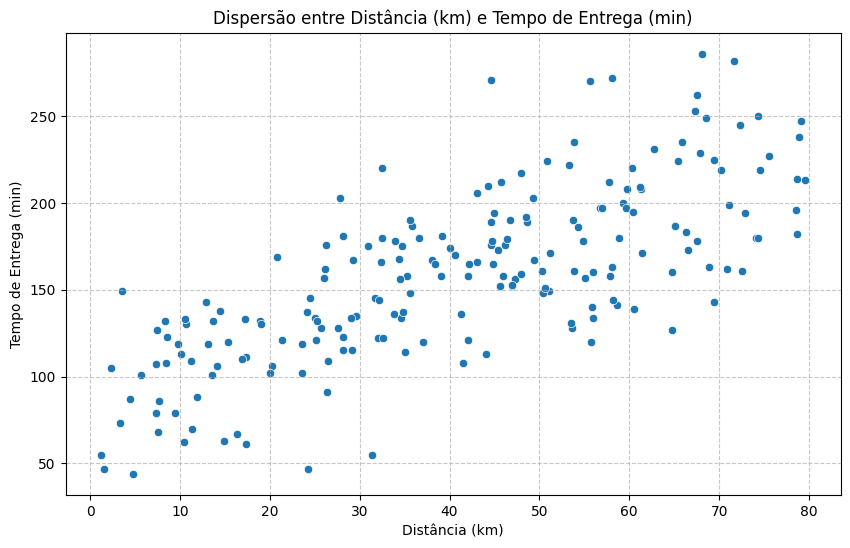

In [23]:
#EX-51
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distancia_km', y='tempo_entrega_min', data=df)
plt.title('Dispersão entre Distância (km) e Tempo de Entrega (min)')
plt.xlabel('Distância (km)')
plt.ylabel('Tempo de Entrega (min)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#EX-52
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distancia_km', y='tempo_entrega_min', data=df, label='Tempo Real')
plt.plot(df['distancia_km'], df['tempo_previsto_min'], color='red', label='Linha de Regressão')
plt.title('Dispersão entre Distância (km) e Tempo de Entrega (min) com Reta de Regressão')
plt.xlabel('Distância (km)')
plt.ylabel('Tempo de Entrega (min)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
#EX-53
#SIm

In [27]:
#EX-54
#SIM, POSSIVEIS OUTLIERS

In [ ]:
#EX-55
#Outliers

# Parte G – Fazendo previsões reais

Use o modelo simples com distância.

## Exercício 56
Preveja o tempo de entrega para uma entrega de 5 km.

## Exercício 57
Preveja o tempo de entrega para uma entrega de 20 km.

## Exercício 58
Preveja o tempo de entrega para uma entrega de 60 km.

## Exercício 59
As previsões fazem sentido?

## Exercício 60
Quais informações importantes o modelo simples está ignorando?

In [ ]:
#EX-56
distancia_5km = pd.DataFrame({'distancia_km': [5]})
tempo_previsto_5km = modelo.predict(distancia_5km)
print(f'Tempo de entrega previsto para 5 km: {tempo_previsto_5km[0][0]:.2f} minutos')

In [ ]:
#EX-57
distancia_20km = pd.DataFrame({'distancia_km': [20]})
tempo_previsto_20km = modelo.predict(distancia_20km)
print(f'Tempo de entrega previsto para 20 km: {tempo_previsto_20km[0][0]:.2f} minutos')

In [ ]:
#EX-58
distancia_60km = pd.DataFrame({'distancia_km': [60]})
tempo_previsto_60km = modelo.predict(distancia_60km)
print(f'Tempo de entrega previsto para 60 km: {tempo_previsto_60km[0][0]:.2f} minutos')

In [ ]:
#EX-59
#

In [ ]:
#EX-60
#

# Parte H – Tratamento de variáveis categóricas

Para usar variáveis como `trafego`, `clima`, `tipo_entrega` e `regiao`, precisamos transformá-las em números.

Uma forma comum é usar `pd.get_dummies()`.

## Exercício 61
Crie uma versão da base com variáveis categóricas transformadas em dummies.

## Exercício 62
Mostre as primeiras linhas da base transformada.

## Exercício 63
Explique o que o `get_dummies()` fez.

## Exercício 64
Por que usamos `drop_first=True`?

## Exercício 65
Quais novas colunas foram criadas?

In [28]:
# Exemplo inicial para a Parte H

df_modelo = pd.get_dummies(
    df,
    columns=["trafego", "clima", "tipo_entrega", "regiao"],
    drop_first=True
)

df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,tempo_previsto_min,erro,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,184.969064,24.969064,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,128.397263,9.397263,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,120.190860,-11.809140,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,165.064171,-10.935829,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,188.111942,30.111942,False,True,False,True,False,False,False


In [29]:
#EX-61
df_modelo = pd.get_dummies(
    df,
    columns=["trafego", "clima", "tipo_entrega", "regiao"],
    drop_first=True
)

df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,tempo_previsto_min,erro,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,184.969064,24.969064,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,128.397263,9.397263,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,120.190860,-11.809140,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,165.064171,-10.935829,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,188.111942,30.111942,False,True,False,True,False,False,False


In [30]:
#EX-62
df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,tempo_previsto_min,erro,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,184.969064,24.969064,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,128.397263,9.397263,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,120.190860,-11.809140,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,165.064171,-10.935829,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,188.111942,30.111942,False,True,False,True,False,False,False


In [ ]:
#EX-63
# realizou uma conversão de dados categoricos em colunas numericas binarias

In [33]:
#EX-64
'''
'''

'\n'

# Parte I – Regressão linear múltipla

Agora vamos usar várias variáveis ao mesmo tempo.

## Exercício 66
Crie `X` com todas as variáveis explicativas numéricas e dummies.

Não inclua:
- `id_pedido`
- `tempo_entrega_min`
- `atrasou`

## Exercício 67
Crie `y` com `tempo_entrega_min`.

## Exercício 68
Treine um modelo de regressão linear múltipla.

## Exercício 69
Faça previsões.

## Exercício 70
Calcule MAE.

## Exercício 71
Calcule RMSE.

## Exercício 72
Calcule R².

## Exercício 73
Compare com o modelo simples.

## Exercício 74
O modelo múltiplo melhorou?

## Exercício 75
Quais variáveis parecem mais importantes?

In [ ]:
# Espaço para resolver a Parte I

# Parte J – Coeficientes do modelo múltiplo

## Exercício 76
Crie uma tabela com variáveis e coeficientes.

## Exercício 77
Ordene os coeficientes do maior para o menor.

## Exercício 78
Quais coeficientes aumentam o tempo previsto?

## Exercício 79
Quais coeficientes diminuem o tempo previsto?

## Exercício 80
Interprete o coeficiente de `distancia_km`.

## Exercício 81
Interprete o coeficiente de `tipo_entrega_expressa`.

## Exercício 82
Interprete o coeficiente de `trafego_alto`.

## Exercício 83
Interprete o coeficiente de `clima_forte_chuva`.

## Exercício 84
Os sinais dos coeficientes fazem sentido?

## Exercício 85
O que poderia indicar um coeficiente estranho?

In [ ]:
# Espaço para resolver a Parte J

# Parte K – Treino e teste

## Exercício 86
Separe os dados em treino e teste com `test_size=0.3` e `random_state=42`.

## Exercício 87
Treine o modelo nos dados de treino.

## Exercício 88
Faça previsões nos dados de teste.

## Exercício 89
Calcule MAE no teste.

## Exercício 90
Calcule RMSE no teste.

## Exercício 91
Calcule R² no teste.

## Exercício 92
Compare com as métricas do treino.

## Exercício 93
O modelo parece generalizar bem?

## Exercício 94
O que indicaria overfitting?

## Exercício 95
Quais cuidados você teria antes de colocar esse modelo em produção?

In [ ]:
# Espaço para resolver a Parte K

# Parte L – Desafio final: relatório para a empresa

A empresa quer saber se é possível prever o tempo de entrega antes do pedido sair para rota.

## Exercício 96
Treine o melhor modelo que conseguir.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?
2. Qual o erro médio em minutos?
3. Quais variáveis mais influenciam o tempo?
4. O modelo deve ser usado sozinho para tomar decisões?
5. Que melhorias poderiam ser feitas com mais dados?

In [ ]:
# Espaço para resolver a Parte L

# Função auxiliar para avaliação de modelos

Use depois de tentar resolver manualmente.

In [ ]:
def avaliar_regressao(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    return {
        "modelo": nome,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# Fechamento

Com esta lista, você praticou um fluxo mais próximo de um problema real:

- exploração de dados;
- visualização;
- correlação;
- transformação de variáveis categóricas;
- regressão linear simples;
- regressão linear múltipla;
- treino e teste;
- avaliação de modelo;
- interpretação para tomada de decisão.